# Downloading the data and computing log-returns

In [26]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download Apple data
# ----------------------------
ticker = "AAPL"
start_date = "2020-01-01"
end_date   = "2025-12-31"


df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Log-Returns + Histogram + Volatility

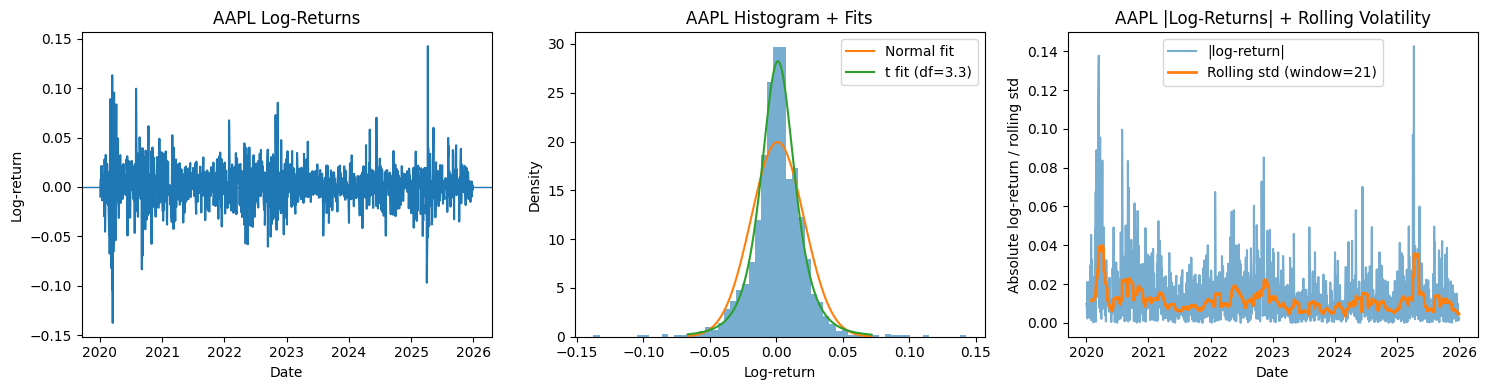

In [27]:
from scipy.stats import norm, t
import numpy as np
import matplotlib.pyplot as plt

# 1) Fit Normal
mu_hat, sigma_hat = np.mean(log_ret), np.std(log_ret, ddof=1)

# 2) Fit Student-t (df, loc, scale)
df_t, loc_t, scale_t = t.fit(log_ret)

# 3) Rolling volatility (std) on absolute returns
abs_ret = log_ret.abs()

# choose a window (e.g. ~1 trading month). Change if you want.
window = 21
roll_std = abs_ret.rolling(window=window).std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (A) Time series of log-returns
axes[0].plot(log_ret.index, log_ret.values)
axes[0].axhline(0, linewidth=1)
axes[0].set_title(f"{ticker} Log-Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log-return")

# (B) Histogram + fitted PDFs
axes[1].hist(log_ret, bins=60, density=True, alpha=0.6)
xmin, xmax = np.percentile(log_ret, [0.5, 99.5])
grid = np.linspace(xmin, xmax, 500)

axes[1].plot(grid, norm.pdf(grid, loc=mu_hat, scale=sigma_hat), label="Normal fit")
axes[1].plot(grid, t.pdf(grid, df=df_t, loc=loc_t, scale=scale_t), label=f"t fit (df={df_t:.1f})")

axes[1].set_title(f"{ticker} Histogram + Fits")
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Density")
axes[1].legend()

# (C) Absolute returns + rolling std
axes[2].plot(abs_ret.index, abs_ret.values, alpha=0.6, label="|log-return|")
axes[2].plot(roll_std.index, roll_std.values, linewidth=2, label=f"Rolling std (window={window})")
axes[2].set_title(f"{ticker} |Log-Returns| + Rolling Volatility")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Absolute log-return / rolling std")
axes[2].legend()

plt.tight_layout()
plt.savefig("hist_apple_1x3.png", dpi=200)
plt.show()



# Autocorrelations

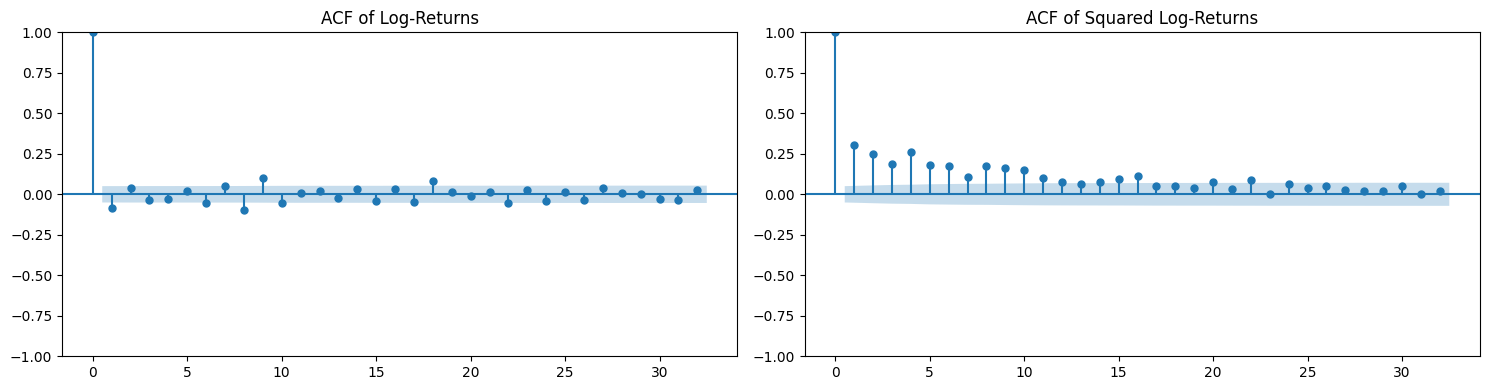

In [28]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ACF of log-returns
plot_acf(log_ret, ax=axes[0])
axes[0].set_title("ACF of Log-Returns")

# ACF of squared log-returns
plot_acf(log_ret**2, ax=axes[1])
axes[1].set_title("ACF of Squared Log-Returns")

# Adjust layout and save
plt.tight_layout()
plt.savefig("ACFs.png", dpi=300)
plt.show()


# Fitting Best AR + GARCH Model

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 24.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from arch import arch_model

# Initialize variables for tracking the best model
best_model = None
best_bic = np.inf
best_order = (0, 0, 0)  # (AR order, GARCH p, GARCH q)

# Search over combinations of AR(p), GARCH(p), and GARCH(q) parameters
for p in range(7):  # AR order
    for garch_p in range(1, 7):  # GARCH p (exclude 0 for GARCH)
        for garch_q in range(0, 7):
            try:
                # Fit AR(p) + GARCH(p, q) model
                model = arch_model(100*log_ret, mean='AR', lags=p, vol='Garch', p=garch_p, q=garch_q, dist = 't')
                result = model.fit(disp="off")

                # Track the best model based on BIC
                if result.bic < best_bic:
                    best_bic = result.bic
                    best_model = result
                    best_order = (p, garch_p, garch_q)
            except Exception as e:
                # Handle any errors during model fitting
                print(f"Error with AR({p}) + GARCH({garch_p}, {garch_q}): {e}")

# Display the best model summary
print(f"Best AR order: {best_order[0]}, Best GARCH orders: ({best_order[1]}, {best_order[2]})")
print(f"Best BIC: {best_bic}")



Best AR order: 0, Best GARCH orders: (1, 1)
Best BIC: 5922.470159877499


# Fitting the Best Model

In [29]:
model = arch_model(100*log_ret, mean='AR', lags=0, vol='Garch', p=1, q=1, dist = 't')
result = model.fit(disp="off")
print(result.summary())

                              AR - GARCH Model Results                              
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                              AR   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2942.94
Distribution:      Standardized Student's t   AIC:                           5895.88
Method:                  Maximum Likelihood   BIC:                           5922.47
                                              No. Observations:                 1506
Date:                      Mon, Feb 09 2026   Df Residuals:                     1505
Time:                              17:23:10   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const     

# Fitting AR(1) + ARCH(1) Model

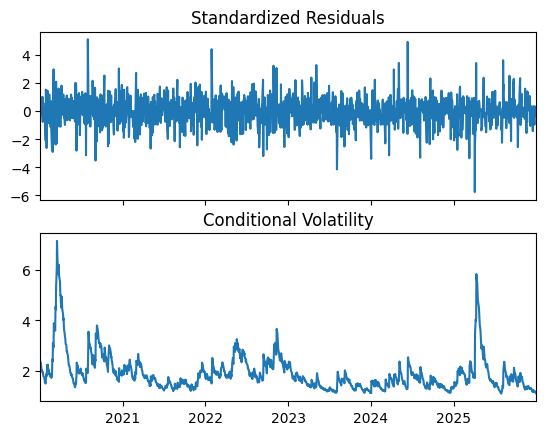

In [30]:
result.plot()
plt.savefig("outtino.png", dpi=300)
plt.show()

# Nicer Output Plots

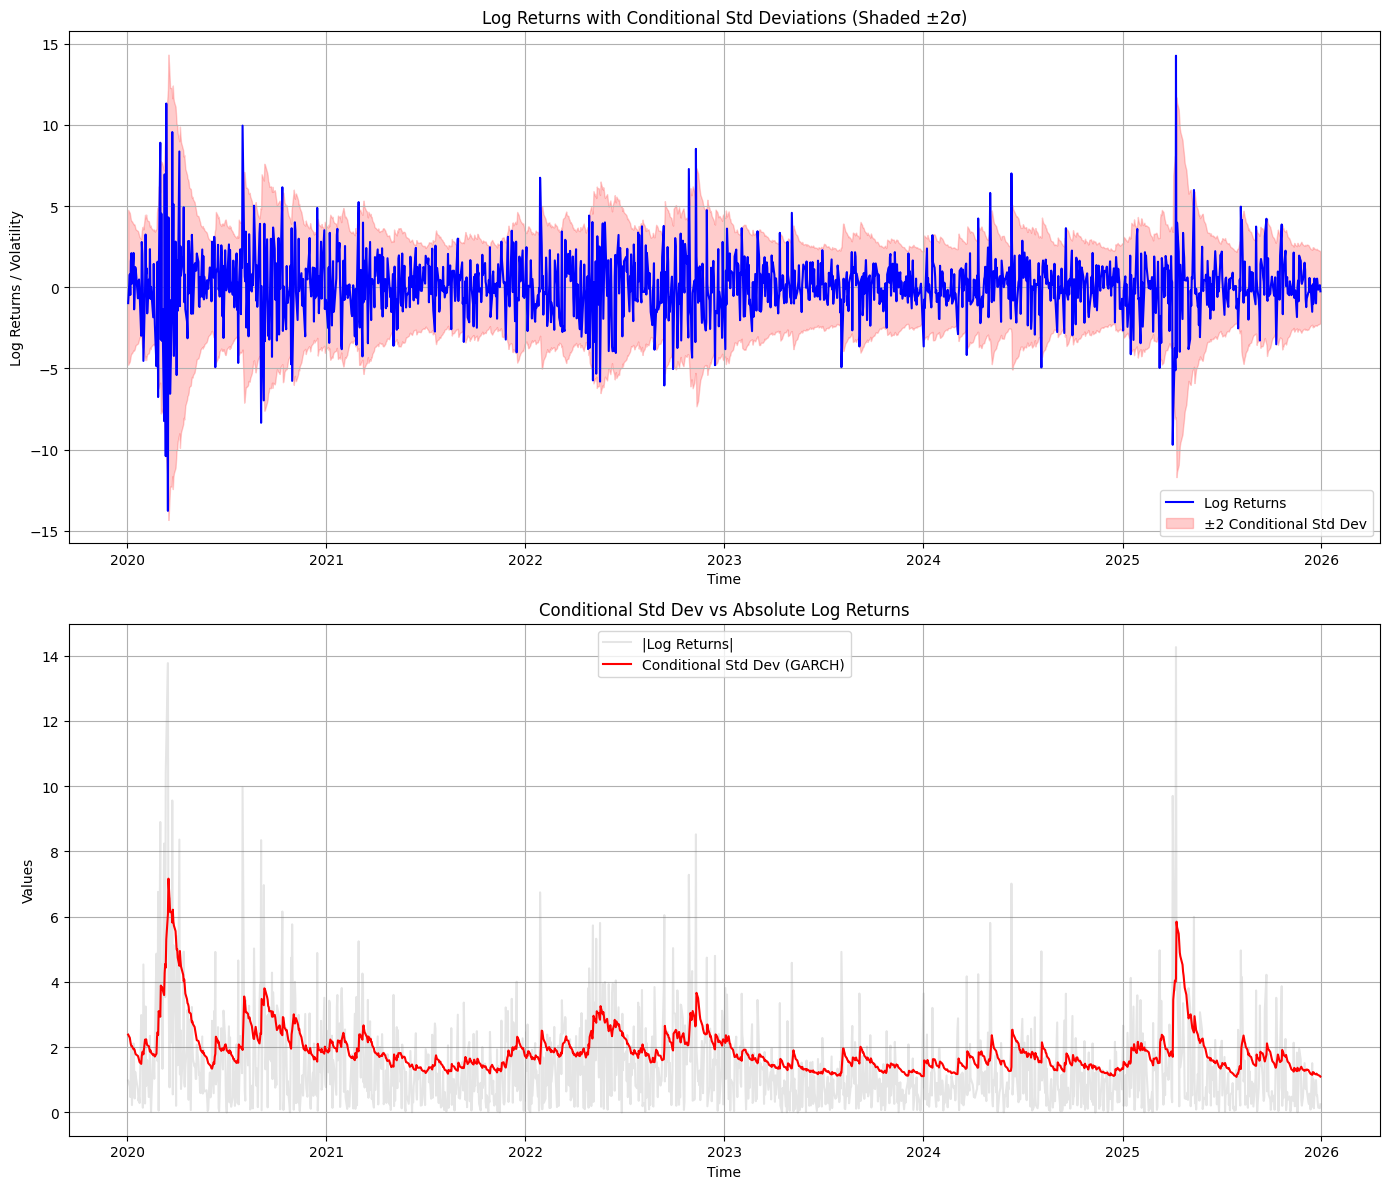

In [ ]:
# Get the conditional volatility (sigma_t) and standardized residuals
conditional_volatility = result.conditional_volatility
absolute_log_returns = np.abs(log_ret)

# Combined plot with two subplots stacked vertically
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Log returns with shaded ±2 conditional standard deviations
axs[0].plot(100*log_ret, label='Log Returns', color='blue')
upper_bound = 2 * conditional_volatility
lower_bound = -2 * conditional_volatility
axs[0].fill_between(log_ret.index, lower_bound, upper_bound, color='red', alpha=0.2, label='±2 Conditional Std Dev')
axs[0].set_title('Log Returns with Conditional Std Deviations (Shaded ±2σ)')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Log Returns / Volatility')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Conditional Std Dev vs. Absolute Log Returns
axs[1].plot(100*absolute_log_returns, label='|Log Returns|', color='gray', alpha=0.2)
axs[1].plot(conditional_volatility, label='Conditional Std Dev (GARCH)', color='red')
axs[1].set_title('Conditional Std Dev vs Absolute Log Returns')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Values')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('combined_garch_plots.png', dpi=300)
plt.show()


# Residuals Plots

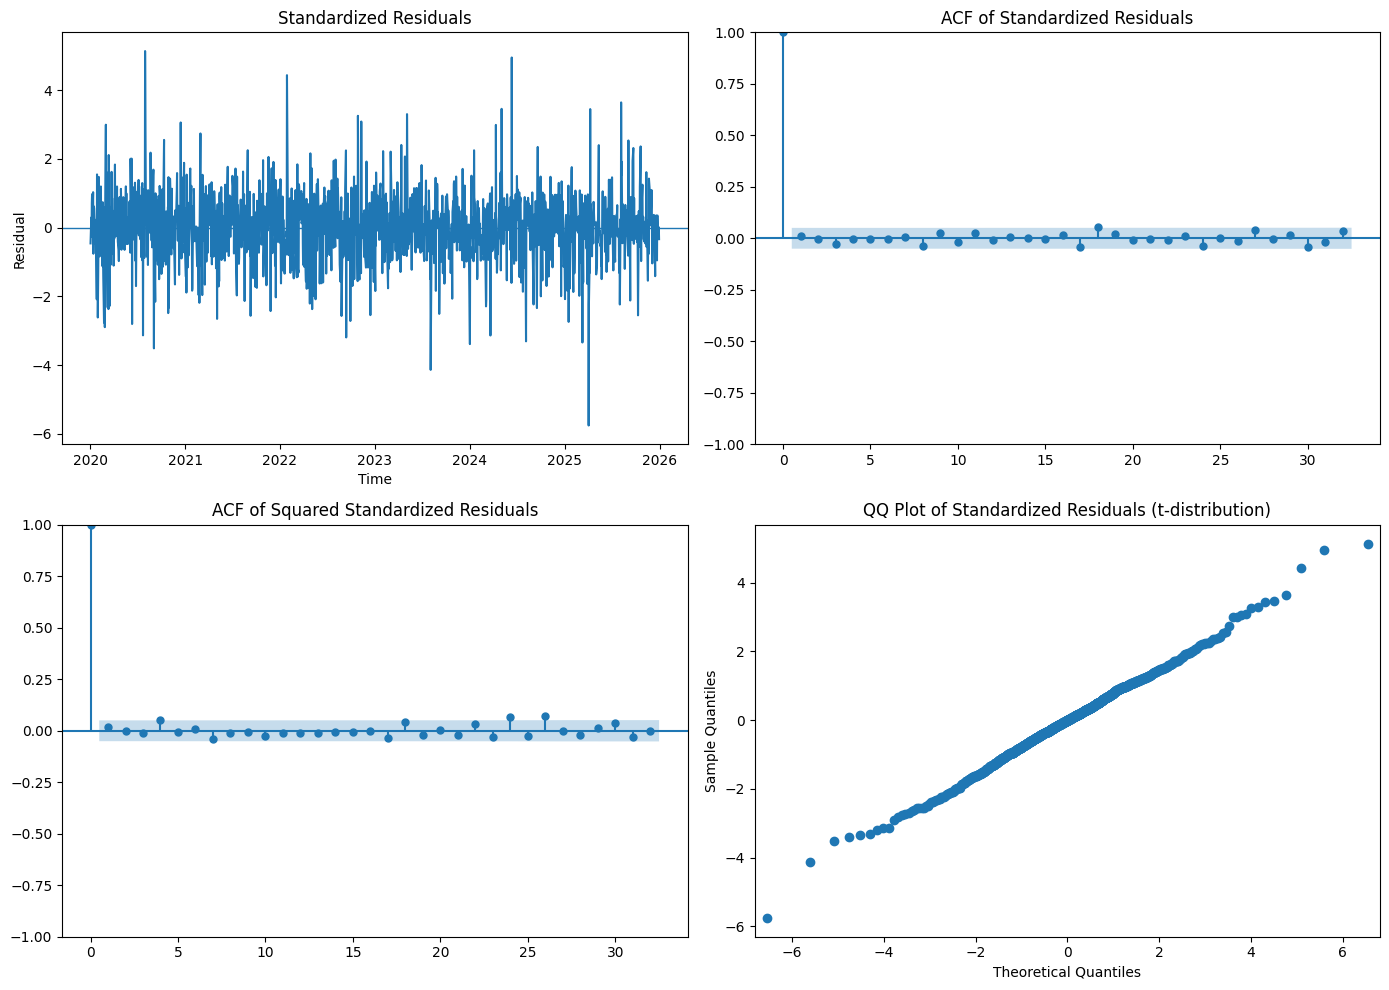

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from scipy.stats import t
import matplotlib.pyplot as plt

# Extract standardized residuals
std_residuals = result.std_resid
std_residuals_squared = std_residuals ** 2
df = result.params['nu']

# Create 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# (1) Time series of standardized residuals
axs[0, 0].plot(std_residuals)
axs[0, 0].axhline(0, linewidth=1)
axs[0, 0].set_title("Standardized Residuals")
axs[0, 0].set_xlabel("Time")
axs[0, 0].set_ylabel("Residual")

# (2) ACF of standardized residuals
plot_acf(std_residuals, ax=axs[0, 1])
axs[0, 1].set_title("ACF of Standardized Residuals")

# (3) ACF of squared standardized residuals
plot_acf(std_residuals_squared, ax=axs[1, 0])
axs[1, 0].set_title("ACF of Squared Standardized Residuals")

# (4) QQ plot of standardized residuals (t-distribution)
sm.qqplot(std_residuals, dist=t, distargs=(df,), ax=axs[1, 1])
axs[1, 1].set_title("QQ Plot of Standardized Residuals (t-distribution)")

# Adjust layout and save
plt.tight_layout()
plt.savefig("diagnostics_2x2.png", dpi=300)
plt.show()


# GJR-GARCH

In [ ]:
model = arch_model(
    100*log_ret,
    mean='AR',  # Use AR for the mean model
    lags=0,     # AR(1) component
    vol='GARCH',  # Use APARCH model
    p=1, o = 1, q=1,   # GARCH(p,q) order
    dist='t'  # Student's t distribution
)
result = model.fit(disp="off")
print(result.summary())

                            AR - GJR-GARCH Model Results                            
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                              AR   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2935.88
Distribution:      Standardized Student's t   AIC:                           5883.76
Method:                  Maximum Likelihood   BIC:                           5915.66
                                              No. Observations:                 1506
Date:                      Mon, Feb 09 2026   Df Residuals:                     1505
Time:                              17:13:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const     